In [1]:
# Limit the number of threads used by various libraries to avoid oversubscription
import os
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["OPENBLAS_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["VECLIB_MAXIMUM_THREADS"] = "6"
os.environ["NUMEXPR_NUM_THREADS"] = "6"

In [ ]:
import os
import pandas as pd
df = pd.read_csv(".data/IJBS/ijbs_still_benchmark_scores_with_roc.csv")

df = df[df["ROC"].notna()]
df.info()


# List all the IDs that has the ROC score and keep only those rows. 

# output_dir = ".data/IJBS/Explanations-with-kprpe-score-decision"
# output_dir = ".data/IJBS/Explanations-with-scores-gt"
output_dir = ".data/IJBS/Explanations-with-no-info"

# model_name = "gpt-4o"
# model_name="gemini-2.5-flash"

model_name="gpt-5.2"
explanation_files = os.listdir(os.path.join(output_dir, model_name))

explanation_files= [x.split('.')[0] for x in explanation_files]

pair_id_set = set(df['pair_id'])

remove_count = 0
for exp_file in explanation_files:
    if exp_file not in pair_id_set:
        # Remove the files from the directory
        remove_count +=1
        try:
            # os.remove(os.path.join(output_dir, model_name, f"{exp_file}.txt"))
            print("Removed", exp_file+'.txt file' )
        except Exception as e:
            print("Problem")


print("removed ", remove_count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9485 entries, 0 to 9484
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pair_id                9485 non-null   object 
 1   image1                 9485 non-null   object 
 2   image2                 9485 non-null   object 
 3   id1                    9485 non-null   int64  
 4   id2                    9485 non-null   int64  
 5   label                  9485 non-null   int64  
 6   part                   9485 non-null   object 
 7   gpt-4o-mini            9485 non-null   float64
 8   KPRPE                  9485 non-null   float64
 9   AdaFace                9485 non-null   float64
 10  ArcFace                9485 non-null   float64
 11  FaceNet_vggface2       9485 non-null   float64
 12  MagFace                9485 non-null   float64
 13  CosFace                9485 non-null   float64
 14  FaceNet_casia_webface  9485 non-null   float64
 15  with

In [14]:
df.to_csv(".data/IJBS/ijbs_still_benchmark_scores_with_roc.csv", index=False)

### CBFACE Embedding Generation

In [ ]:
import os
import re
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from openai import OpenAI



def extract_and_validate(text):
    
    # Split the text into lines first
    lines = text.split('\n')

    # Find the line in which "Match Verdict:" appears
    match_verdict_line = next((i for i, line in enumerate(lines) if "Match Verdict:" in line), None)
    if match_verdict_line is None:
        return False, "Error: 'Match Verdict:' section not found." 

    for i, line in enumerate(lines):
        if "Match Verdict:" in line:
            match_verdict_line = i
        if "Similarities:" in line:
            similarities_line = i
        if "Differences:" in line:
            differences_line = i
        if "Overall Reasoning:" in line:
            overall_reasoning_line = i

    try:   

        if (similarities_line+6)  == differences_line + 3 == overall_reasoning_line:
            return True, "\n".join(lines[match_verdict_line:overall_reasoning_line + 2])
        else: 
            return False, f"Error: Section formatting issue."
    except:
        return False, f"Error: Section formatting issue."
		





client = OpenAI()


# IMAGES_DIR = ".data/BUPT-CBFace-12-top-100/images"
# METADATA_FILE = ".data/BUPT-CBFace-12-top-100/cbface_top100_pairs_scores.csv"
# OUTPUT_DIR = ".data/BUPT-CBFace-12-top-100/Explanations"
# EMBED_DIR = ".data/BUPT-CBFace-12-top-100/Embeddings"

# IMAGES_DIR = ".data/IJBS/IJBS-Still"
METADATA_FILE = ".data/IJBS/ijbs_still_benchmark_scores_roc.csv"
OUTPUT_DIR = ".data/IJBS/Explanations-with-kprpe-score-decision"
# MODEL_NAME = "gpt-4o" 
MODEL_NAME = "gpt-5.2"
# MODEL_NAME = 'gemini-2.5-flash'

EMBEDDING_MODEL = "text-embedding-3-small"
# EMBEDDING_MODEL = "text-embedding-3-large"


EXPL_DIR = os.path.join(OUTPUT_DIR, MODEL_NAME)
SAVE_JSONL = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_{EMBEDDING_MODEL}_embeddings.jsonl")
BATCH_SIZE = 64


# ---------------------------------------------------------------------
# Load explanation text
# ---------------------------------------------------------------------
def load_and_clean(path):
    with open(path, "r") as f:
        lines = f.read()
        if MODEL_NAME.startswith("gpt-4o"):
            parserd, cleaned = extract_and_validate(lines)
        else:
            parserd, cleaned = True, lines

        if parserd:
            return cleaned
        else:
            os.remove(path)
            print("Removed format error", path)
            return None



paths = sorted([
    os.path.join(EXPL_DIR, f)
    for f in os.listdir(EXPL_DIR)
    if f.endswith(".txt")
])

texts, pair_ids = [], []
for p in paths:
    pair_id = os.path.splitext(os.path.basename(p))[0]
    text = load_and_clean(p)

    if text is not None:
        pair_ids.append(pair_id)
        texts.append(text)

print(f"Loaded {len(paths)} explanation files.")
print(f"{len(texts)} explanation files passed validation.")


# ---------------------------------------------------------------------
# Load already processed embeddings (resume capability)
# ---------------------------------------------------------------------
processed = {}

if os.path.exists(SAVE_JSONL):
    print("Resuming from existing JSONL...")
    with open(SAVE_JSONL, "r") as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                processed[obj["pair_id"]] = obj["embedding"]

print(f"Loaded {len(processed)} previously processed embeddings.")


# ---------------------------------------------------------------------
# Decide which samples still need embedding
# ---------------------------------------------------------------------
remaining_ids = []
remaining_texts = []

for pid, txt in zip(pair_ids, texts):
    if pid not in processed:
        remaining_ids.append(pid)
        remaining_texts.append(txt)

print(f"{len(remaining_ids)} items remaining to embed.")

# if ID is bad remove the exaplanation file
bad_ids = []

# ---------------------------------------------------------------------
# Process remaining embeddings batch-by-batch
# ---------------------------------------------------------------------
for i in tqdm(
        range(0, len(remaining_texts), BATCH_SIZE),
        total=(len(remaining_texts) + BATCH_SIZE - 1) // BATCH_SIZE
    ):
    
    batch_ids = remaining_ids[i:i+BATCH_SIZE]
    batch_txt = remaining_texts[i:i+BATCH_SIZE]

    try:
        response = client.embeddings.create(
            input=batch_txt,
            model=EMBEDDING_MODEL
        )

        batch_emb = [x.embedding for x in response.data]

        # Save immediately (checkpointing)
        with open(SAVE_JSONL, "a") as f:
            for pid, emb in zip(batch_ids, batch_emb):
                f.write(json.dumps({"pair_id": pid, "embedding": emb}) + "\n")

        # Update processed dict in memory
        for pid, emb in zip(batch_ids, batch_emb):
            processed[pid] = emb

    except Exception as e:
        print("\n❌ ERROR in batch", i // BATCH_SIZE + 1, ":", e)
        print("Skipping this batch and continuing...")
        print(batch_ids, batch_txt)
        bad_ids.extend(batch_ids)               


        continue


print("\n✔ All embeddings processed.")
print(f"Total embeddings: {len(processed)}")

print(f"Bad IDs: {bad_ids}")

Loaded 9485 explanation files.
9485 explanation files passed validation.
Loaded 0 previously processed embeddings.
9485 items remaining to embed.


100%|██████████| 149/149 [01:41<00:00,  1.46it/s]


✔ All embeddings processed.
Total embeddings: 9485
Bad IDs: []


### Clustering and Sanity Checking

Loaded data stat:
Embeddings:  10000
Labels:  10000
pair_ids:  10000
Embedding shape: (10000, 1536)
t-SNE done.


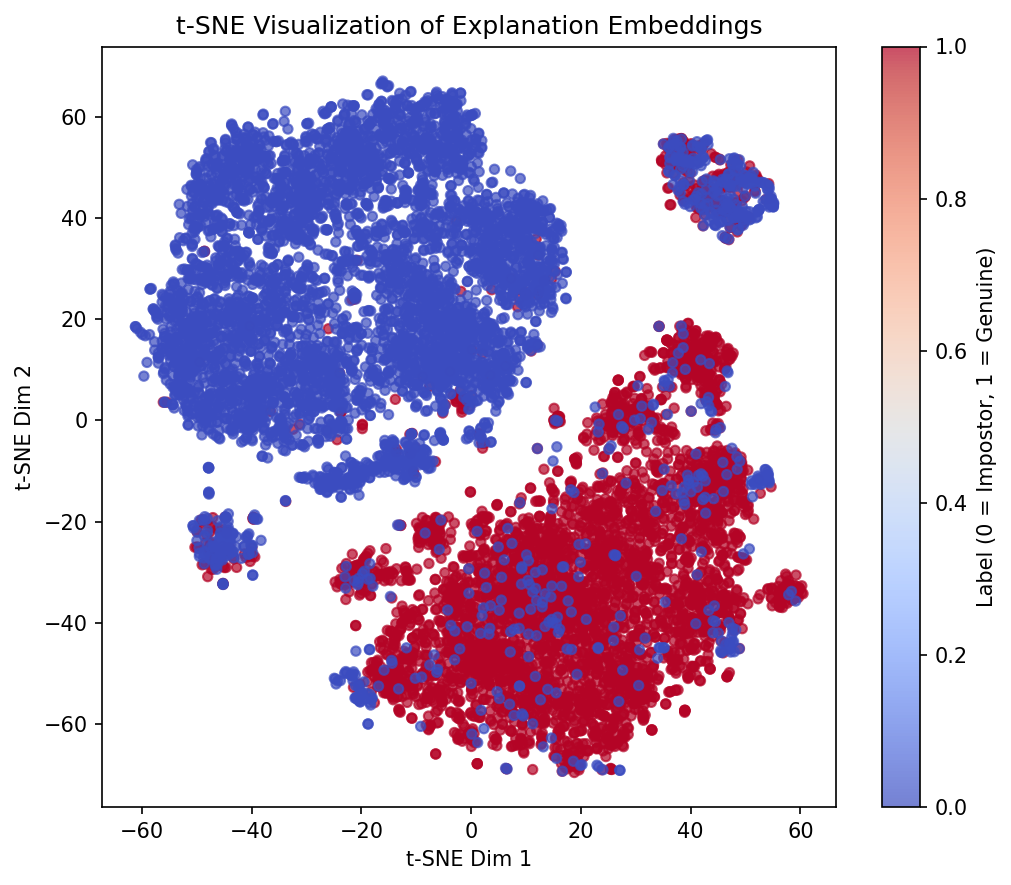

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
import os

# --------------------------
# 1. Build DataFrame
# --------------------------
# JSONL_PATH = ".data/BUPT-CBFace-12-top-100/Embeddings/explanation_embeddings.jsonl"
JSONL_PATH = ".data/IJBS/Explanations-with-scores-gt/gemini-2.5-flash_embeddings.jsonl"
METADATA_IJBS_PATH = ".data/IJBS/ijbs_still_benchmark_scores.csv"
# METADATA_CBFACE_PATH = ".data/BUPT-CBFace-12-top-100/cbface_top100_pairs_scores.csv"


df = pd.read_csv(METADATA_IJBS_PATH)

processed = {}

with open(JSONL_PATH, 'r') as f:
    for line in f:
        item = json.loads(line)
        pid = item["pair_id"]
        emb = np.array(item["embedding"], dtype=float)
        processed[pid] = emb

pair_ids = list(processed.keys())
embeddings = np.array(list(processed.values()), dtype=float)



# --------------------------
# 2. Load metadata + attach labels
# --------------------------
# df = pd.read_csv(".data/BUPT-CBFace-12-top-100/cbface_top100_pairs_scores.csv")

# Make the pair_id the index for easy mapping
df.set_index('pair_id', inplace=True)
labels = np.array([df.loc[pid, 'label'] for pid in pair_ids], dtype=int)

print("Loaded data stat:")
print("Embeddings: ", len(embeddings))
print("Labels: ", len(labels))
print("pair_ids: ", len(pair_ids))


print("Embedding shape:", embeddings.shape)   # Expect (N, D)

# ---------------------------------------
# Run 2D t-SNE
# ---------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init='random',
    random_state=42
)

coords = tsne.fit_transform(embeddings)
print("t-SNE done.")

# ---------------------------------------
# Plot the result
# ---------------------------------------
plt.figure(figsize=(7,6), dpi=150)

scatter = plt.scatter(
    coords[:,0],
    coords[:,1],
    c=labels,
    cmap="coolwarm",
    alpha=0.7,
    s=20
)

plt.title("t-SNE Visualization of Explanation Embeddings")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")

cbar = plt.colorbar(scatter)
cbar.set_label("Label (0 = Impostor, 1 = Genuine)")

plt.tight_layout()
os.makedirs("results/gemini-2.5-flash", exist_ok=True)
plt.savefig("results/gemini-2.5-flash/tsne_of_ijbs_embeddings.png", dpi=200) 
plt.show()



In [3]:
# Save the t-SNE coordinates and labels with pair_ids to a CSV file
output_df = pd.DataFrame({
    'pair_id': pair_ids,
    'tsne_x': coords[:, 0],
    'tsne_y': coords[:, 1],
    'label': labels
})
output_df.to_csv(".data/IJBS/Explanations-with-scores-gt/gemini-2.5-flash_tsne.csv", index=False)

In [ ]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from openai import OpenAI

client = OpenAI()

EXPL_DIR = "GeneratedOutputs/gpt-4o"
EMBED_DIR = "GeneratedOutputs/gpt-4o/"
SAVE_JSONL = os.path.join(EMBED_DIR, "lfw_combined_openai_explanation_embeddings.jsonl")

dataframe_file = "GeneratedOutputs/gpt-4o/lfw_combined_explanations.csv"
df = pd.read_csv(dataframe_file)



BATCH_SIZE = 128

os.makedirs(EMBED_DIR, exist_ok=True)


# ---------------------------------------------------------------------
# Load explanation text
# ---------------------------------------------------------------------
def load_and_clean(path):
    with open(path, "r") as f:
        lines = f.read().split("\n")
    return "\n".join(lines[4:]).strip()


paths = sorted([
    os.path.join(EXPL_DIR, f)
    for f in os.listdir(EXPL_DIR)
    if f.endswith(".txt")
])

# pair_ids = [os.path.splitext(os.path.basename(p))[0] for p in paths]
# texts = [load_and_clean(p) for p in paths]

texts = df['parsed_json'].to_list()
pair_ids = df['pair_id'].to_list()
labels = df['label'].to_list()

print(f"Loaded {len(paths)} explanation files.")


# ---------------------------------------------------------------------
# Load already processed embeddings (resume capability)
# ---------------------------------------------------------------------
processed = {}

if os.path.exists(SAVE_JSONL):
    print("Resuming from existing JSONL...")
    with open(SAVE_JSONL, "r") as f:
        for line in f:
            if line.strip():
                obj = json.loads(line)
                processed[obj["pair_id"]] = obj["embedding"]

print(f"Loaded {len(processed)} previously processed embeddings.")


# ---------------------------------------------------------------------
# Decide which samples still need embedding
# ---------------------------------------------------------------------
remaining_ids = []
remaining_texts = []

for pid, txt in zip(pair_ids, texts):
    if pid not in processed:
        remaining_ids.append(pid)
        remaining_texts.append(txt)

print(f"{len(remaining_ids)} items remaining to embed.")



# ---------------------------------------------------------------------
# Process remaining embeddings batch-by-batch
# ---------------------------------------------------------------------
for i in tqdm(
        range(0, len(remaining_texts), BATCH_SIZE),
        total=(len(remaining_texts) + BATCH_SIZE - 1) // BATCH_SIZE
    ):
    
    batch_ids = remaining_ids[i:i+BATCH_SIZE]
    batch_txt = remaining_texts[i:i+BATCH_SIZE]
    labels_batch = labels[i:i+BATCH_SIZE]

    try:
        response = client.embeddings.create(
            input=batch_txt,
            model="text-embedding-3-small"
        )

        batch_emb = [x.embedding for x in response.data]

        # Save immediately (checkpointing)
        with open(SAVE_JSONL, "a") as f:
            for pid, lbl, emb in zip(batch_ids, labels_batch, batch_emb):
                f.write(json.dumps({"pair_id": pid, "label": lbl, "embedding": emb}) + "\n")

        # Update processed dict in memory
        for pid, emb in zip(batch_ids, batch_emb):
            processed[pid] = emb

    except Exception as e:
        print("\n❌ ERROR in batch", i // BATCH_SIZE + 1, ":", e)
        print("Skipping this batch and continuing...")
        print(batch_ids, batch_txt)
        bad_ids.extend(batch_ids)


        continue


print("\n✔ All embeddings processed.")
print(f"Total embeddings: {len(processed)}")


Loaded 0 explanation files.
Loaded 0 previously processed embeddings.
6000 items remaining to embed.


100%|██████████| 47/47 [00:50<00:00,  1.08s/it]


✔ All embeddings processed.
Total embeddings: 3000


NameError: name 'bad_ids' is not defined